🔍 正在大三巴牌坊商圈寻觅对决双方...
🥊 【红方 - 网红巨头】: 玛嘉烈蛋挞店 Cafe e Nata Margaret's (评论数: 18600, 网红打卡: 5)
🥊 【蓝方 - 深巷老店】: 澳门顺兴悦美味坊 Estabelecimento de Comidas Shun Xing Yue (评论数: 92, 本土程度: 4)

🎲 启动蒙特卡罗模拟：生成 1000 个具有随机偏好的独立游客...
📊 模拟完成！在 1000 次对决中：
   ➤ 网红巨头获胜次数: 698
   ➤ 深巷老店逆袭次数: 302 (逆袭率: 30.2%)


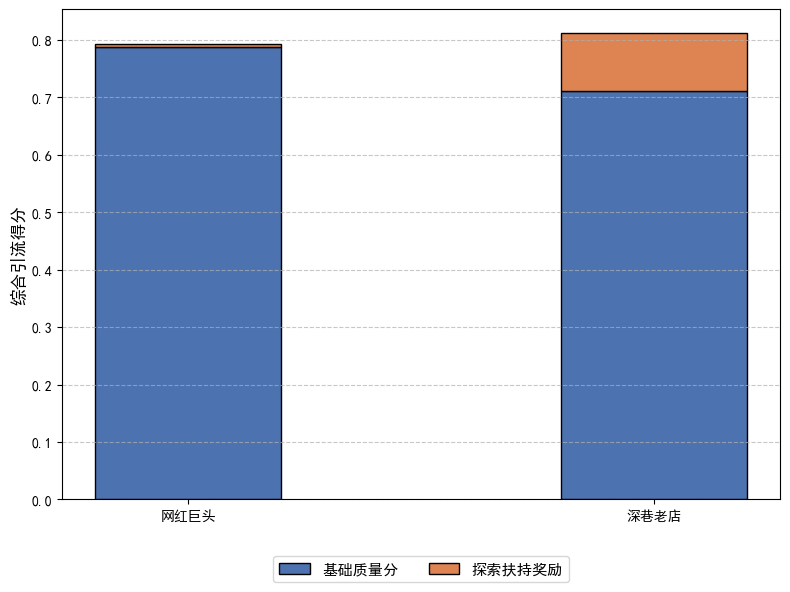

In [6]:
# ==========================================
# 澳门景点智能推荐系统 - 模型三深度验证
# 对抗“马太效应”的逆袭推演（双雄对决）
# ==========================================

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# ================== 1. Colab 中文显示环境配置 ==================
# 自动下载中文字体以防 Colab 图表中文乱码
if not os.path.exists('/tmp/SimHei.ttf'):
    !wget -qO /tmp/SimHei.ttf https://raw.githubusercontent.com/StellarCN/scp_zh/master/fonts/SimHei.ttf
fm.fontManager.addfont('/tmp/SimHei.ttf')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ================== 2. 数据准备与双雄提取 ==================
# 读取商户数据 (支持原 xlsx 或 csv 格式)
try:
    merchants_df = pd.read_csv('正式景点_商铺数据.xlsx - 表1.csv')
except:
    merchants_df = pd.read_excel('正式景点_商铺数据.xlsx', sheet_name='表1')

# 锁定场景：大三巴牌坊附近的餐饮
dasanba_food = merchants_df[(merchants_df['景点名称'] == '大三巴牌坊') & (merchants_df['业态'].str.contains('餐饮', na=False))]
v_max = merchants_df['网络评论数'].max() # 全局最大评论数

print("🔍 正在大三巴牌坊商圈寻觅对决双方...")

# 角色 A：资本雄厚的网红餐厅 (高评论、高网红打卡分)
wanghong_candidates = dasanba_food.sort_values(by=['网络评论数', '网红打卡'], ascending=[False, False])
wanghong_shop = wanghong_candidates.iloc[0]

# 角色 B：深巷里的正宗老店 (低评论、高本土程度、高评分)
laodian_candidates = dasanba_food[(dasanba_food['网络评论数'] < 100) & (dasanba_food['网络评分'] >= 4.0)]
laodian_shop = laodian_candidates.sort_values(by=['本土程度', '网络评分'], ascending=[False, False]).iloc[0]

print(f"🥊 【红方 - 网红巨头】: {wanghong_shop['商户名称']} (评论数: {wanghong_shop['网络评论数']}, 网红打卡: {wanghong_shop['网红打卡']})")
print(f"🥊 【蓝方 - 深巷老店】: {laodian_shop['商户名称']} (评论数: {laodian_shop['网络评论数']}, 本土程度: {laodian_shop['本土程度']})")

# ================== 3. 核心计算函数 ==================
def cosine_similarity(v1, v2):
    dot = np.dot(v1, v2)
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    return 0.0 if n1 == 0 or n2 == 0 else dot / (n1 * n2)

def calculate_model_components(user_vec, shop):
    """拆解模型三的得分：返回 总分, 基础质量分(靠口碑), 探索奖励分(靠低曝光)"""
    feat = np.array([shop['网红打卡']/5, shop['本土程度']/5, shop['环境氛围']/5])
    M_ij = cosine_similarity(user_vec, feat)

    R, v = shop['网络评分'], shop['网络评论数']

    # 贝叶斯平滑
    w = v / (v + 30)
    Q = w * R + (1 - w) * 3.5

    # 探索奖励计算 (评论越少，V越大)
    E = math.log10(v + 1) / math.log10(v_max + 1)
    V = 1 - E

    # 得分拆解
    base_score = M_ij * (Q / 5)       # 质量基础盘
    explore_bonus = M_ij * 0.2 * V    # 流量扶持盘(逆袭核心)
    total_score = base_score + explore_bonus

    return total_score, base_score, explore_bonus

# ================== 4. 蒙特卡罗方法：1000次随机推演 ==================
print("\n🎲 启动蒙特卡罗模拟：生成 1000 个具有随机偏好的独立游客...")
np.random.seed(42)
# 游客偏好 [网红打卡, 本土程度, 环境氛围] 分别在 1~5 之间随机
user_prefs = np.random.randint(1, 6, size=(1000, 3))

wanghong_wins = 0
laodian_wins = 0

# 用于画图的数据累加器（针对“偏好本土文化”的细分人群）
target_users = 0
avg_w_base, avg_w_bonus = 0, 0
avg_l_base, avg_l_bonus = 0, 0

for pref in user_prefs:
    w_tot, w_base, w_bonus = calculate_model_components(pref, wanghong_shop)
    l_tot, l_base, l_bonus = calculate_model_components(pref, laodian_shop)

    # 记录胜负
    if l_tot > w_tot:
        laodian_wins += 1
    elif w_tot > l_tot:
        wanghong_wins += 1

    # 提取真正关注“本土程度”的游客群体 (本土偏好 >= 4) 来做深度剖析
    if pref[1] >= 4:
        target_users += 1
        avg_w_base += w_base
        avg_w_bonus += w_bonus
        avg_l_base += l_base
        avg_l_bonus += l_bonus

# 计算平均分
avg_w_base /= target_users
avg_w_bonus /= target_users
avg_l_base /= target_users
avg_l_bonus /= target_users

print(f"📊 模拟完成！在 1000 次对决中：")
print(f"   ➤ 网红巨头获胜次数: {wanghong_wins}")
print(f"   ➤ 深巷老店逆袭次数: {laodian_wins} (逆袭率: {(laodian_wins/1000)*100:.1f}%)")

# ================== 5. 可视化：拆解式堆叠柱状图 (純淨版) ==================
# 簡化標籤名稱，去除多餘文字
labels = ['网红巨头', '深巷老店']
base_scores = [avg_w_base, avg_l_base]
bonus_scores = [avg_w_bonus, avg_l_bonus]

fig, ax = plt.subplots(figsize=(8, 6))

# 绘制堆叠柱状图
bar_width = 0.4
p1 = ax.bar(labels, base_scores, bar_width, label='基础质量分', color='#4C72B0', edgecolor='black')
p2 = ax.bar(labels, bonus_scores, bar_width, bottom=base_scores, label='探索扶持奖励', color='#DD8452', edgecolor='black')

# 圖表基礎設定 (已移除柱子上的數字與紅色註解文字)
#ax.set_title('核心受众群得分构成拆解', fontsize=15, pad=15)
ax.set_ylabel('综合引流得分', fontsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

🔍 正在加载数据并锁定大三巴牌坊的【餐饮美食类】店铺...
✅ 成功提取 357 家餐饮美食类商铺。

🎲 正在生成 10000 名随机偏好游客，进行单业态深度推演...

🏆 餐饮业态推荐分配统计完成！
【传统算法】大店推荐几率: 100.0%  | 小店推荐几率: 0.0%
【完整模型】大店推荐几率: 72.4%  | 小店推荐几率: 27.6%


/tmp/ipykernel_1290/772720214.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=12)


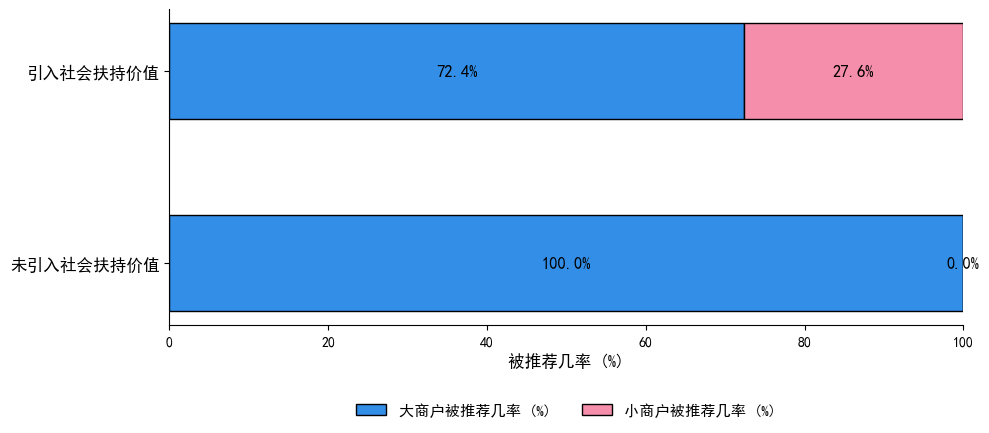

In [32]:
# ==========================================
# 澳门景点智能推荐系统 - 单一业态推演
# 聚焦大三巴牌坊【餐饮美食类】，计算大店小店推荐几率
# ==========================================

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# ================== 1. Colab 中文显示环境配置 ==================
if not os.path.exists('/tmp/SimHei.ttf'):
    os.system("wget -qO /tmp/SimHei.ttf https://raw.githubusercontent.com/StellarCN/scp_zh/master/fonts/SimHei.ttf")
fm.fontManager.addfont('/tmp/SimHei.ttf')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ================== 2. 数据准备与场景锁定 ==================
print("🔍 正在加载数据并锁定大三巴牌坊的【餐饮美食类】店铺...")
try:
    merchants_df = pd.read_csv('正式景点_商铺数据.xlsx - 表1.csv')
except:
    merchants_df = pd.read_excel('正式景点_商铺数据.xlsx', sheet_name='表1')

# 仅筛选大三巴牌坊，且业态为餐饮类的商铺
dasanba_food = merchants_df[(merchants_df['景点名称'] == '大三巴牌坊') & (merchants_df['业态'].str.contains('餐饮', na=False))].copy()

# 定义大店与小店 (以评论数 300 为分水岭)
dasanba_food['Size_Label'] = dasanba_food['网络评论数'].apply(lambda x: '大店 (高曝光)' if x >= 300 else '小店 (深巷长尾)')
v_max = merchants_df['网络评论数'].max() # 全局最大评论数作为基准

# 预计算质量分 Q 和 探索因子 V
dasanba_food['Q_score'] = dasanba_food.apply(
    lambda r: (r['网络评论数']/(r['网络评论数']+30))*r['网络评分'] + (30/(r['网络评论数']+30))*3.5, axis=1
)
dasanba_food['V_score'] = dasanba_food['网络评论数'].apply(
    lambda v: 1 - (math.log10(v+1) / math.log10(v_max+1))
)

print(f"✅ 成功提取 {len(dasanba_food)} 家餐饮美食类商铺。")

# ================== 3. 蒙特卡罗模拟分配 (10000游客) ==================
np.random.seed(42) # 固定种子
num_tourists = 10000
user_prefs = np.random.randint(1, 6, size=(num_tourists, 3)) # [网红打卡, 本土程度, 环境氛围]

print(f"\n🎲 正在生成 {num_tourists} 名随机偏好游客，进行单业态深度推演...\n")

# 记录分配结果 (总计 10000 次选择)
results = {
    'Full_Model': {'大店 (高曝光)': 0, '小店 (深巷长尾)': 0},
    'Ablated_Model': {'大店 (高曝光)': 0, '小店 (深巷长尾)': 0}
}

# 提取特征矩阵并归一化，提升计算效率
feats = dasanba_food[['网红打卡', '本土程度', '环境氛围']].values / 5.0
norms = np.linalg.norm(feats, axis=1)
norms[norms == 0] = 1 # 防止除以 0

Q_arr = dasanba_food['Q_score'].values / 5.0
V_arr = dasanba_food['V_score'].values
shop_sizes = dasanba_food['Size_Label'].values

for pref in user_prefs:
    # 游客偏好向量归一化
    pref_norm = pref / (np.linalg.norm(pref) or 1)

    # 计算 M_ij (属性匹配度)
    M_ij = np.dot(feats, pref_norm) / norms

    # --- 对比逻辑 ---
    # 1. 消融模型 (传统算法：移除 0.2V 扶持，只看质量 Q 和匹配 M)
    score_ablated = M_ij * Q_arr
    winner_ablated_idx = np.argmax(score_ablated)
    results['Ablated_Model'][shop_sizes[winner_ablated_idx]] += 1

    # 2. 完整模型三 (含 0.2V 探索扶持)
    score_full = M_ij * (Q_arr + 0.2 * V_arr)
    winner_full_idx = np.argmax(score_full)
    results['Full_Model'][shop_sizes[winner_full_idx]] += 1

# ================== 4. 计算几率 (概率统计) ==================
prob_ablated_big = (results['Ablated_Model']['大店 (高曝光)'] / num_tourists) * 100
prob_ablated_small = (results['Ablated_Model']['小店 (深巷长尾)'] / num_tourists) * 100

prob_full_big = (results['Full_Model']['大店 (高曝光)'] / num_tourists) * 100
prob_full_small = (results['Full_Model']['小店 (深巷长尾)'] / num_tourists) * 100

print("🏆 餐饮业态推荐分配统计完成！")
print(f"【传统算法】大店推荐几率: {prob_ablated_big:.1f}%  | 小店推荐几率: {prob_ablated_small:.1f}%")
print(f"【完整模型】大店推荐几率: {prob_full_big:.1f}%  | 小店推荐几率: {prob_full_small:.1f}%")

# ================== 5. 可视化：水平比例堆叠图 ==================
labels = ['未引入社会扶持价值', '引入社会扶持价值']
big_shop_probs = [prob_ablated_big, prob_full_big]
small_shop_probs = [prob_ablated_small, prob_full_small]

fig, ax = plt.subplots(figsize=(10, 4.5))

# 绘制水平堆叠图 (加入 alpha=0.7 调低不透明度)
# 底层：大店 (蓝色)
p1 = ax.barh(labels, big_shop_probs, height=0.5, label='大商户被推荐几率 (%)', color='#338EE8', edgecolor='black', alpha=1)
# 上层：小店 (红色)，叠加在大店的宽度之上
p2 = ax.barh(labels, small_shop_probs, left=big_shop_probs, height=0.5, label='小商户被推荐几率 (%)', color='#F58EAA', edgecolor='black', alpha=1)

# 图表装饰 (纯净学术风)
ax.set_xlabel('被推荐几率 (%)', fontsize=12)
ax.set_xlim(0, 100) # 强制 X 轴到 100%
ax.set_yticklabels(labels, fontsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=11, frameon=False)

# 去除多余的边框线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 在色块正中心填充百分比数值
for i in range(len(labels)):
    # 大店数值定位 (居中)
    ax.text(big_shop_probs[i] / 2, i, f'{big_shop_probs[i]:.1f}%',
            ha='center', va='center', color='black', fontsize=12, fontweight='bold')
    # 小店数值定位 (大店宽度 + 小店宽度的一半)
    ax.text(big_shop_probs[i] + small_shop_probs[i] / 2, i, f'{small_shop_probs[i]:.1f}%',
            ha='center', va='center', color='black', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
